In [ ]:
!pip install -q datasets insightface onnxruntime-gpu opencv-python-headless tqdm

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [ ]:
import cv2
import numpy as np
from datasets import load_dataset
import insightface
from insightface.app import FaceAnalysis
from tqdm.notebook import tqdm

Initalize the engine (Arcface) from github

In [ ]:
print("Loading Model...")
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

Loading Model...
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionP

Loading dataset

In [ ]:
dataset_stream = load_dataset("tonyassi/celebrity-1000", split="train", streaming=True)

Data Augmentation

In [ ]:
def rotate_image(image, angle):
    """Rotates an image correctly around its center."""
    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    result = cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)
    return result

Visulaization

In [ ]:
sample_viz = next(iter(dataset_stream))
img_bgr_orig = cv2.cvtColor(np.array(sample_viz['image']), cv2.COLOR_RGB2BGR)

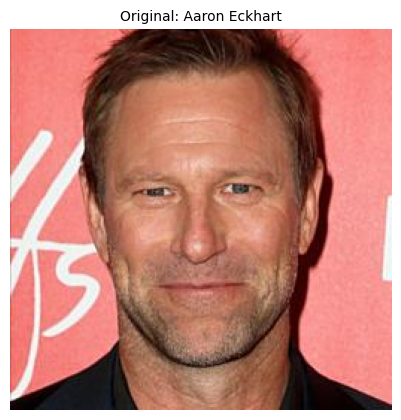

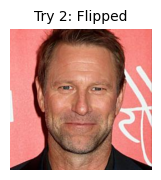

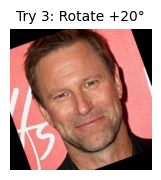

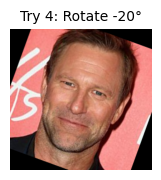

In [ ]:
# 5. Plot them side-by-side with the name in the title
titles = [
    f"Original: {display_name}",
    "Try 2: Flipped",
    "Try 3: Rotate +20°",
    "Try 4: Rotate -20°"
]
images = [img_bgr_orig, var_flip, var_rot_plus, var_rot_minus]

plt.figure(figsize=(16, 14))
for i in range(4):
    plt.subplot(1, 4, i+1)
    # Convert back to RGB for correct matplotlib display
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i], fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


Initalize Engine "Arcface"

In [ ]:
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640), det_thresh=0.3)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

Processing loop

In [ ]:
print("Starting Intelligent Processing Loop...")
X_list = []
y_list = []

Starting Intelligent Processing Loop...


Extract Embeddings

In [ ]:
processed_count = 0
recovered_count = 0
TOTAL_ESTIMATE = 15300

print("Starting Smart Processing Pipeline...")
print("Strategy: Efficient 'Waterfall' approach (Original -> Flip -> Rotations).")

# Re-connect stream specifically for the main loop iteration
dataset_stream_main = load_dataset("tonyassi/celebrity-1000", split="train", streaming=True)

for i, sample in enumerate(tqdm(dataset_stream_main, total=TOTAL_ESTIMATE, desc="Processing")):
    try:
        # Load base image
        img_bgr = cv2.cvtColor(np.array(sample['image']), cv2.COLOR_RGB2BGR)

        # Define the sequence of attempts. We stop as soon as one works.
        attempts = [
            ("Original", img_bgr),
            ("Flipped", cv2.flip(img_bgr, 1)),
            ("Rotated +15", rotate_image(img_bgr, 15)),
            ("Rotated -15", rotate_image(img_bgr, -15))
        ]

        face_found_in_sequence = False

        for attempt_name, img_variant in attempts:
            faces = app.get(img_variant)

            if len(faces) > 0:
                # SUCCESS! Found a face.
                # Select the largest face if multiple are present
                target_face = sorted(faces, key=lambda x: (x.bbox[2]-x.bbox[0]) * (x.bbox[3]-x.bbox[1]))[-1]

                # Save data
                X_list.append(target_face.normed_embedding)
                y_list.append(sample['label'])
                processed_count += 1
                face_found_in_sequence = True

                # If it wasn't the original attempt, log it as a recovery
                if attempt_name != "Original":
                    recovered_count += 1

                # IMPORTANT: Stop trying other variations for this image. Move to next.
                break

        if not face_found_in_sequence:
            # All attempts failed. Image is definitively unusable. Skip.
            continue

    except Exception as e:
        # Handle corrupted file errors gracefully
        continue

print("\n" + "="*40)
print("PIPELINE COMPLETE")
print("="*40)
print(f"Total high-quality faces secured: {processed_count}")
print(f"Saved by augmentation strategy:     {recovered_count}")
print("="*40)
print("The dataset is clean and maximized for recovery. Ready for saving.")

Starting Smart Processing Pipeline...
Strategy: Efficient 'Waterfall' approach (Original -> Flip -> Rotations).


Processing:   0%|          | 0/15300 [00:00<?, ?it/s]


PIPELINE COMPLETE
✅ Total high-quality faces secured: 4060
✨ Saved by augmentation strategy:     1479
The dataset is clean and maximized for recovery. Ready for saving.


In [ ]:
print("Converting lists to efficient Numpy tensors...")
# Use float32 for high-precision embeddings (standard for deep learning)
X_final = np.array(X_list, dtype=np.float32)
# Use int32 for labels
y_final = np.array(y_list, dtype=np.int32)

print(f"Final Features shape: {X_final.shape}")
print(f"Final Labels shape:   {y_final.shape}")

print("\nSaving data to .npy binary files (Industry Standard for Precision/Speed)...")
np.save("my_X_arcface.npy", X_final)
np.save("my_y_arcface.npy", y_final)

print("\n SUCCESS! Data saved successfully.")
print("Files ready for Notebook 2: 'my_X_arcface.npy' and 'my_y_arcface.npy'")

Converting lists to efficient Numpy tensors...
Final Features shape: (4060, 512)
Final Labels shape:   (4060,)

Saving data to .npy binary files (Industry Standard for Precision/Speed)...

 SUCCESS! Data saved successfully.
Files ready for Notebook 2: 'my_X_arcface.npy' and 'my_y_arcface.npy'


In [ ]:
import json

print("Extracting label mapping (the 'decoder ring')...")
# Load dataset metadata to get the feature info
ds_metadata = load_dataset("tonyassi/celebrity-1000", split="train")
label_features = ds_metadata.features['label']

# Create a dictionary mapping every integer index to its string name
# e.g., {0: "Aaron_Eckhart", 1: "Adam_Sandler", ...}
num_classes = label_features.num_classes
idx_to_class_mapping = {i: label_features.int2str(i) for i in range(num_classes)}

mapping_filename = "celebrity_name_mapping.json"
print(f"Saving mapping dictionary to '{mapping_filename}'...")

# Save dictionary to a standard JSON file
with open(mapping_filename, 'w') as f:
    json.dump(idx_to_class_mapping, f)

print(f"\n✅ SUCCESS! Mapping saved.")
print(f"IMPORTANT: Download '{mapping_filename}' alongside your .npy files.")
print("You will need this file for the final inference notebook to display actual names.")

Extracting label mapping (the 'decoder ring')...
Saving mapping dictionary to 'celebrity_name_mapping.json'...

✅ SUCCESS! Mapping saved.
IMPORTANT: Download 'celebrity_name_mapping.json' alongside your .npy files.
You will need this file for the final inference notebook to display actual names.
